# Revenue Forecast — Linear Regression Baseline

Builds a linear regression baseline for monthly revenue forecasting.

**Dataset:** [Online Retail II](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci) — place the file at `data/online_retail_II.xlsx`

## 1. Load & Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

df = pd.read_excel("data/online_retail_II.xlsx")
df['Revenue'] = df['Price'] * df['Quantity']
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [2]:
# Aggregate to monthly level
monthly_revenue = df.groupby('Month').agg({
    'Invoice': 'nunique',
    'Quantity': 'sum',
    'Revenue': 'sum',
    'Customer ID': 'nunique'
}).reset_index()

# Drop the last (incomplete) month
monthly_revenue = monthly_revenue[:-1]
print(f"Total months available: {len(monthly_revenue)}")
monthly_revenue

Total months available: 12


,Month,Invoice,Quantity,Revenue,Customer ID
0,2009-12,2330,420088,799847.110,1045
1,2010-01,1633,375363,624032.892,786
2,2010-02,1969,368402,533091.426,807
3,2010-03,2367,489370,765848.761,1111
4,2010-04,1892,351971,590580.432,998
5,2010-05,2418,364095,615322.830,1062
6,2010-06,2216,388253,679786.610,1095
7,2010-07,2017,302201,575236.360,988
8,2010-08,1877,451803,656776.340,964
9,2010-09,2375,478262,853650.431,1202


## 2. Visualise Monthly Revenue

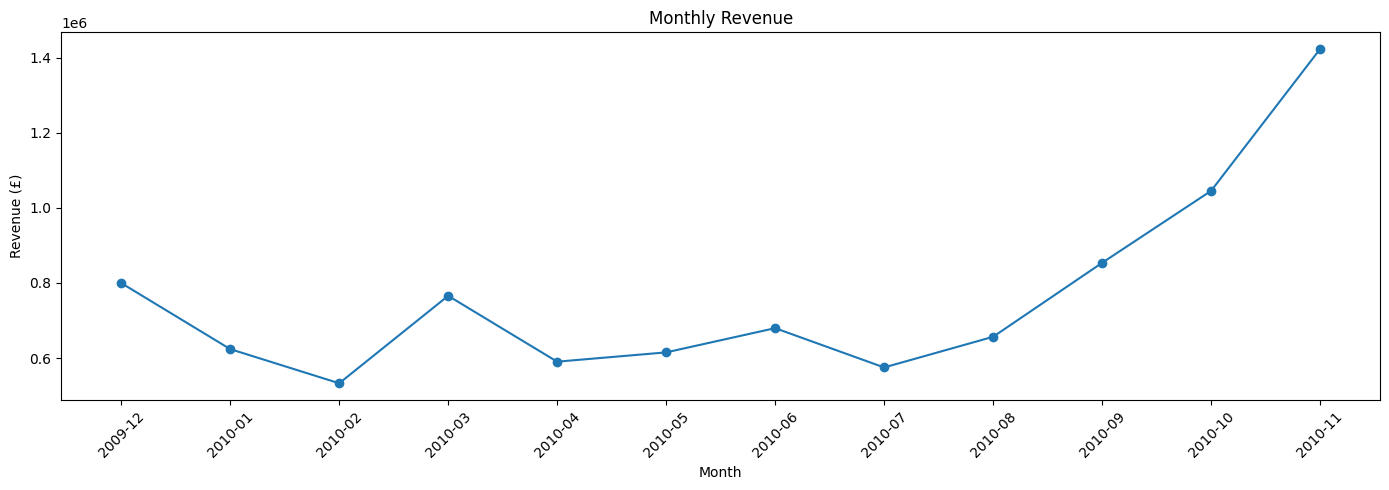

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['Month'].astype(str), monthly_revenue['Revenue'], marker='o')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Feature Engineering

Three features:
- `Time` — linear trend index
- `Month_num` — captures seasonality
- `is_Q4` — flags Oct/Nov/Dec where revenue spikes due to holiday demand

In [4]:
monthly_revenue['Time'] = range(len(monthly_revenue))
monthly_revenue['Month_num'] = monthly_revenue['Month'].dt.month
monthly_revenue['is_Q4'] = monthly_revenue['Month_num'].isin([10, 11, 12]).astype(int)

X = monthly_revenue[['Time', 'Month_num', 'is_Q4']]
y = monthly_revenue['Revenue']

## 4. Train / Test Split

In [5]:
# Hold out last 2 months (Nov + Dec 2010) as test set
X_train, X_test = X[:-2], X[-2:]
y_train, y_test = y[:-2], y[-2:]

print(f"Train: {X_train.shape[0]} months ({monthly_revenue['Month'].iloc[0]} to {monthly_revenue['Month'].iloc[-3]})")
print(f"Test:  {X_test.shape[0]} months ({monthly_revenue['Month'].iloc[-2]} to {monthly_revenue['Month'].iloc[-1]})")

Train: 10 months (2009-12 to 2010-09)
Test:  2 months (2010-10 to 2010-11)


## 5. Train Model & Evaluate

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("=== Training performance ===")
print(f"R²:   {r2_score(y_train, y_pred_train):.3f}")
print(f"MAE:  £{mean_absolute_error(y_train, y_pred_train):,.0f}")

print("\n=== Test performance ===")
print(f"R²:   {r2_score(y_test, y_pred_test):.3f}")
print(f"MAE:  £{mean_absolute_error(y_test, y_pred_test):,.0f}")

print("\nActual:   ", y_test.values)
print("Predicted:", y_pred_test.round(0))

=== Training performance ===
R²:   0.358
MAE:  £64,049

=== Test performance ===
R²:   -6.538
MAE:  £485,791

Actual:    [1045168.35  1422654.642]
Predicted: [739808. 756433.]


## 6. Plot Actual vs Predicted

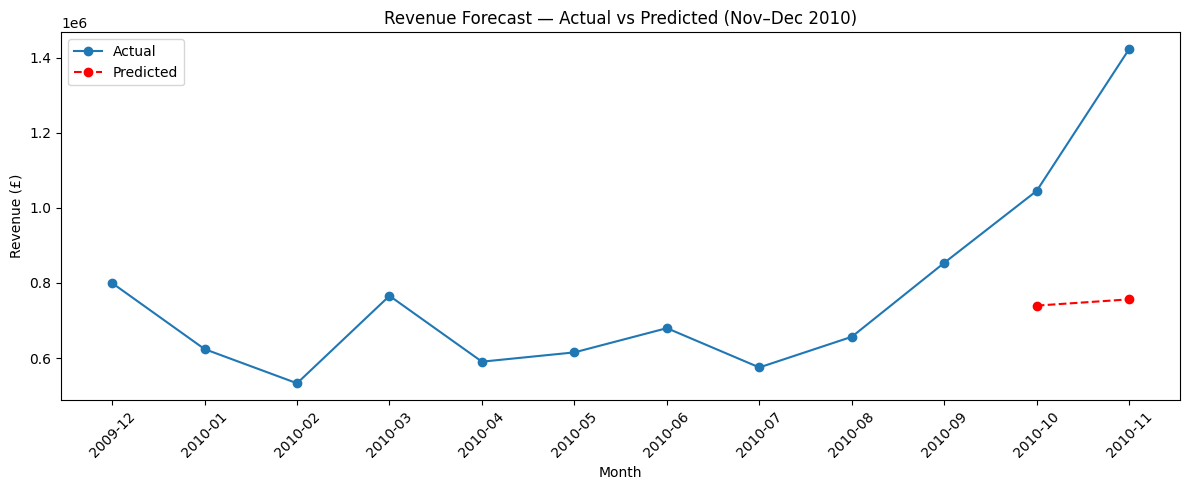

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['Month'].astype(str),
         monthly_revenue['Revenue'],
         marker='o', label='Actual')
plt.plot(monthly_revenue['Month'].astype(str)[-2:],
         y_pred_test,
         marker='o', linestyle='--', color='red', label='Predicted')
plt.title('Revenue Forecast — Actual vs Predicted (Nov–Dec 2010)')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Analysis & Limitations

**Why does the test R² look poor?**

The dataset covers only 13 months (Dec 2009 – Dec 2010). The test set is Nov and Dec 2010 — the holiday season peak. The model was trained on only **one prior Q4 month** (Dec 2009), so it cannot reliably learn the full magnitude of the seasonal spike.

The training R² confirms the model fits historical data well — the problem is **generalisation with very limited data**, not a broken model.

**Key takeaway:** Linear regression is a valid baseline. With 3+ years of data, the seasonal pattern would be learnable. For production use:
- **Facebook Prophet** or **SARIMA** are better suited for short time series with strong seasonality
- **Walk-forward cross-validation** is more appropriate than a fixed holdout for time series evaluation
